In [24]:
import pandas as pd
import os
import sqlite3
import selenium
import sys
import matplotlib

# Add the backend folder to the Python path
backend_dir = os.path.join(os.getcwd(), 'backend')
if backend_dir not in sys.path:
    sys.path.append(backend_dir)



### Play

In [8]:
from utils.historical_stock_data_processor import HistoricalStockDataProcessor
self = HistoricalStockDataProcessor()


In [31]:
company_info = self.load_data(table_name=self.config.company_table, db_filepath=self.config.metadados_filepath)
company_info

  100.00% (1+0), 0.0010s per item, 0h 00m 00s = 0h 00m 00s + 0h 00m 00s Parte 1/1 metadados.db company_info


,cvm_code,company_name,ticker,ticker_codes,isin_codes,trading_name,sector,subsector,segment,listing,activity,registrar,cnpj,website
0,900049,1461 INVESTIMENTOS SA,UQMU,[],[],1461 INVEST,,,,,,,,
1,900025,3R POTIGUAR SA,PTGU,[],[],3RPOTIGUAR,,,,,,,,
2,908830,3Z REALTY DESENVOLVIMENTO IMOBILIARIO SA,TZRD,[],[],3ZREALTY,NAO CLASSIFICADOS,NAO CLASSIFICADO,NAO CLASSIFICADOS,,,,08145855000112,
3,16284,524 PARTICIPACOES SA,QVQP,"[""QVQP3""]","[""BRQVQPACNOR1""]",524 PARTICIP,OUTROS,OUTROS,OUTROS,,Holding - participação em outras sociedades,ITAU CORRETORA ACOES,01851771000155,http://www.524participacoes.com.br/home/index....
4,900391,99 PAY INSTITUICAO DE PAGAMENTO SA,NNPY,[],[],99 PAY,,,,,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2898,None,XTRACKERS MSCI EUROPE UCITS ETF,BEUR,None,None,XTRACKEREUR,None,None,None,BDR DE ETF,None,None,None,None
2899,None,XTRACKERS MSCI JAPAN UCITS ETF,BJAP,None,None,XTRACKERJAP,None,None,None,BDR DE ETF,None,None,None,None
2900,None,XTRACKERS MSCI USA UCITS ETF,BEUA,None,None,XTRACKERUSA,None,None,None,BDR DE ETF,None,None,None,None
2901,None,XTRACKERS MSCI WORLD ENERGY UCITS ETF,BLUZ,None,None,XTRACKERENGY,None,None,None,BDR DE ETF,None,None,None,None


In [9]:
historical_stock_data = self.load_data(table_name=self.config.historical_data, db_filepath=self.config.metadados_filepath)


  6.25% (1+15), 0.0005s per item, 0h 00m 00s = 0h 00m 00s + 0h 00m 00s Parte 1/16 metadados.db historical_data
  12.50% (2+14), 0.5073s per item, 0h 00m 08s = 0h 00m 01s + 0h 00m 07s Parte 2/16 metadados.db historical_data
  18.75% (3+13), 0.6717s per item, 0h 00m 10s = 0h 00m 02s + 0h 00m 08s Parte 3/16 metadados.db historical_data
  25.00% (4+12), 0.7554s per item, 0h 00m 12s = 0h 00m 03s + 0h 00m 09s Parte 4/16 metadados.db historical_data
  31.25% (5+11), 0.8063s per item, 0h 00m 12s = 0h 00m 04s + 0h 00m 08s Parte 5/16 metadados.db historical_data
  37.50% (6+10), 0.8392s per item, 0h 00m 13s = 0h 00m 05s + 0h 00m 08s Parte 6/16 metadados.db historical_data
  43.75% (7+9), 0.8633s per item, 0h 00m 13s = 0h 00m 06s + 0h 00m 07s Parte 7/16 metadados.db historical_data
  50.00% (8+8), 0.8811s per item, 0h 00m 14s = 0h 00m 07s + 0h 00m 07s Parte 8/16 metadados.db historical_data
  56.25% (9+7), 0.8950s per item, 0h 00m 14s = 0h 00m 08s + 0h 00m 06s Parte 9/16 metadados.db historical_d

In [15]:
historical_stock_data['company_ticker'] = historical_stock_data['ticker'].str.replace(r'\d', '', regex=True)


<Axes: >

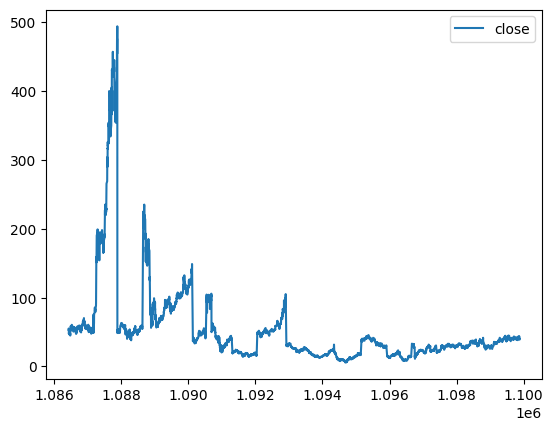

In [30]:
mask = historical_stock_data['company_ticker'] == 'PETR'
mask = historical_stock_data['ticker'] == 'PETR3'
historical_stock_data[mask][['date', 'close']].plot()

### Eventos Corporativos B3

In [11]:
database_path = r'D:\Fausto Stangler\Documentos\Python\FLY\backend\data'
database_file = r'b3.db'
database = os.path.join(database_path + r'/' + database_file)
database

'D:\\Fausto Stangler\\Documentos\\Python\\FLY\\backend\\data/b3.db'

In [18]:
query = """
        SELECT * FROM company_info
        """

with sqlite3.connect(database) as conn:
    company_info = pd.read_sql_query(query, conn)


In [20]:
company_info.head(3)

,cvm_code,company_name,ticker,ticker_codes,isin_codes,trading_name,sector,subsector,segment,listing,activity,registrar,cnpj,website
0,900049,1461 INVESTIMENTOS SA,UQMU,,,1461 INVEST,,,,,,,,
1,25291,3R PETROLEUM OLEO E GAS SA,RRRP,RRRP3,BRRRRPACNOR5,3R PETROLEUM,PETROLEO GAS E BIOCOMBUSTIVEIS,PETROLEO GAS E BIOCOMBUSTIVEIS,EXPLORACAO REFINO E DISTRIBUICAO,CIA NOVO MERCADO,Exploração. produção. refino e comercializaçã...,ITAU CORRETORA ACOES,12091809000155,
2,900025,3R POTIGUAR SA,PTGU,,,3RPOTIGUAR,,,,,,,,


In [23]:
company_info.columns

Index(['cvm_code', 'company_name', 'ticker', 'ticker_codes', 'isin_codes',
       'trading_name', 'sector', 'subsector', 'segment', 'listing', 'activity',
       'registrar', 'cnpj', 'website'],
      dtype='object')

In [28]:
for i, row in company_info.iterrows():
    url = f"https://sistemaswebb3-listados.b3.com.br/listedCompaniesPage/main/{row['cvm_code']}/{row['ticker']}/corporate-actions?language=pt-br"
    print(url)
    break

# 

https://sistemaswebb3-listados.b3.com.br/listedCompaniesPage/main/900049/UQMU/corporate-actions?language=pt-br


In [59]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

# Initialize WebDriver
driver = webdriver.Chrome()  # Ensure you have the appropriate driver installed

# Navigate to the page
url = 'https://sistemaswebb3-listados.b3.com.br/listedCompaniesPage/main/8133/LREN/corporate-actions?language=pt-br'
driver.get(url)


In [56]:
# Wait for the accordion toggle element to be clickable and click it
accordion_xpath = '//*[@id="accordionHeading"]'
WebDriverWait(driver, 10).until(
    EC.element_to_be_clickable((By.XPATH, accordion_xpath))
).click()

# Wait for the accordion content to load/display
content_xpath = '//*[@id="accordionBody"]/div/table'  # Adjust this to match the content's XPath
WebDriverWait(driver, 10).until(
    EC.presence_of_element_located((By.XPATH, content_xpath))
)

# Extract the accordion content
accordion_content = driver.find_element(By.XPATH, content_xpath).text

# Extract the table content_xpath
table_html = driver.find_element(By.XPATH, content_xpath).get_attribute('outerHTML')

# Parse the table HTML into a Pandas DataFrame
df = pd.read_html(table_html)[0]  # Assuming the first table is the one you want


C:\Users\faust\AppData\Local\Temp\ipykernel_14172\3935060812.py:20: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(table_html)[0]  # Assuming the first table is the one you want


In [60]:
# Wait for the accordion toggle element to be clickable and click it
accordion_xpath = '//*[@id="accordionHeadingTwo"]'
WebDriverWait(driver, 10).until(
    EC.element_to_be_clickable((By.XPATH, accordion_xpath))
).click()

# Wait for the accordion content to load/display
content_xpath = '//*[@id="accordionHeadingTwo"]/div/table'  # Adjust this to match the content's XPath
WebDriverWait(driver, 10).until(
    EC.presence_of_element_located((By.XPATH, content_xpath))
)

# Extract the accordion content
accordion_content = driver.find_element(By.XPATH, content_xpath).text

# Extract the table content_xpath
table_html = driver.find_element(By.XPATH, content_xpath).get_attribute('outerHTML')

# Parse the table HTML into a Pandas DataFrame
df = pd.read_html(table_html)[0]  # Assuming the first table is the one you want


TimeoutException: Message: 
Stacktrace:
	GetHandleVerifier [0x00007FF773C4FB05+28789]
	(No symbol) [0x00007FF773BB86E0]
	(No symbol) [0x00007FF773A5592A]
	(No symbol) [0x00007FF773AA930E]
	(No symbol) [0x00007FF773AA95FC]
	(No symbol) [0x00007FF773AF28A7]
	(No symbol) [0x00007FF773ACF47F]
	(No symbol) [0x00007FF773AEF654]
	(No symbol) [0x00007FF773ACF1E3]
	(No symbol) [0x00007FF773A9A938]
	(No symbol) [0x00007FF773A9BAA1]
	GetHandleVerifier [0x00007FF773F8933D+3410093]
	GetHandleVerifier [0x00007FF773F9E7DD+3497293]
	GetHandleVerifier [0x00007FF773F92A73+3448803]
	GetHandleVerifier [0x00007FF773D17BBB+848171]
	(No symbol) [0x00007FF773BC3C3F]
	(No symbol) [0x00007FF773BBF6E4]
	(No symbol) [0x00007FF773BBF87D]
	(No symbol) [0x00007FF773BAED49]
	BaseThreadInitThunk [0x00007FF8D07A259D+29]
	RtlUserThreadStart [0x00007FF8D1F6AF38+40]


In [52]:
df

,Proventos em Ativos,Código ISIN,Deliberado em,Negócios com até,% / Fator de Grupamento,Ativo Emitido,Observação.
0,BONIFICACAO,BRLRENACNOR1,11/12/2024,11/12/2024,1000000000000,BRLRENACNOR1,NaN
1,DESDOBRAMENTO,BRLRENACNOR1,23/09/2015,23/09/2015,40000000000000,BRLRENACNOR1,NaN
2,GRUPAMENTO,BRLRENACNOR1,28/06/2005,29/06/2005,395256920,BRLRENACNOR1,NaN
3,CIS RED CAP,BRLRENACNOR1,30/07/1998,13/11/1998,10000000000000,BRRNPTACNOR0,NaN
4,CIS RED CAP,BRLRENACNOR1,30/07/1998,13/11/1998,10000000000000,BRLRENACNOR1,NaN
5,CIS RED CAP,BRLRENACNPR8,30/07/1998,13/11/1998,10000000000000,BRRNPTACNPR7,NaN
6,CIS RED CAP,BRLRENACNPR8,30/07/1998,13/11/1998,10000000000000,BRLRENACNPR8,NaN
